In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from collections import Counter

PROJECT_ROOT = os.path.abspath("..")
# 2. Imports
from ska_agent.models.embedding import Embedder
from ska_agent.core.pricing import PricingEngine
from shared.constants import LAMBDA_GRID, MODES, MODE_COLORS, LAMBDA_BINS, EPS, TARGET_K_BY_MODE
from shared.corpus import make_officeqa_synthetic_corpus, build_segments_from_texts
from shared.scoring import complexity_aligned_lambda_score, get_selected_indices, ensure_1d
from shared.predictor import LambdaPredictor, train_predictor, stratified_train_val_split
from shared.io_utils import load_records

OUT_W6 = os.path.join(PROJECT_ROOT, "outputs", "week6")
OUT_W8 = os.path.join(PROJECT_ROOT, "outputs", "week8")
os.makedirs(OUT_W8, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif',
    'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.axisbelow': True, 'legend.frameon': False
})

print("Loading Embedder...")
embedder = Embedder(model_name="all-MiniLM-L6-v2")

# CRITICAL: N_PER_MODE must match Week 6 generation (Assuming 75 based on previous logs)
N_PER_MODE = 25
print(f"Rebuilding Synthetic Corpus (n_per_mode={N_PER_MODE})...")
segment_texts, questions, relevant_by_qid, _ = make_officeqa_synthetic_corpus(n_per_mode=N_PER_MODE)
segments = build_segments_from_texts(segment_texts, embedder)

corpus_embeddings = np.array([seg.vector for seg in segments], dtype=np.float32)
corpus_norms = np.linalg.norm(corpus_embeddings, axis=1)
corpus_norms[corpus_norms == 0] = 1e-10

train_records = load_records(os.path.join(OUT_W6, "train_sweep_records.json"))
test_records = load_records(os.path.join(OUT_W6, "test_sweep_records.json"))

print(f"Loaded {len(segments)} segments.")
print(f"Loaded {len(train_records)} train records and {len(test_records)} test records.")

Loading Embedder...


'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


No GPU found. Using lightweight CPU embedder: Alibaba-NLP/gte-Qwen2-1.5B-instruct
Loading embedding model: all-MiniLM-L6-v2


RuntimeError: Cannot send a request, as the client has been closed.

In [2]:
def extract_covariance_features(query_emb: np.ndarray, corpus_embs: np.ndarray, c_norms: np.ndarray, top_k: int = 10) -> np.ndarray:
    """Computes both Query-to-Doc density and Doc-to-Doc covariance (redundancy)."""
    q_norm = np.linalg.norm(query_emb)
    if q_norm == 0: q_norm = 1e-10

    # 1. Query-to-Document Similarity (Density)
    q_sims = np.dot(corpus_embs, query_emb) / (c_norms * q_norm)
    sorted_indices = np.argsort(q_sims)[::-1]

    # Extract Density Features (Same as before)
    top_20 = q_sims[sorted_indices[:20]]
    mean_top20 = np.mean(top_20) if len(top_20) > 0 else 0.0
    var_top20 = np.var(top_20) if len(top_20) > 0 else 0.0
    gap_1_5 = top_20[0] - top_20[4] if len(top_20) > 4 else 0.0
    hist_counts, _ = np.histogram(q_sims, bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

    # 2. Document-to-Document Similarity (Covariance / Redundancy)
    # Grab the embeddings of the top K scouted documents
    top_k_indices = sorted_indices[:top_k]
    top_k_embs = corpus_embs[top_k_indices]
    top_k_norms = c_norms[top_k_indices]

    # Normalize and compute the K x K similarity matrix
    normalized_embs = top_k_embs / top_k_norms[:, None]
    cov_matrix = np.dot(normalized_embs, normalized_embs.T)

    # Extract upper triangle (excluding diagonal self-similarity)
    upper_tri_indices = np.triu_indices_from(cov_matrix, k=1)
    pairwise_sims = cov_matrix[upper_tri_indices]

    # Redundancy Statistics
    mean_redundancy = np.mean(pairwise_sims) if len(pairwise_sims) > 0 else 0.0
    max_redundancy = np.max(pairwise_sims) if len(pairwise_sims) > 0 else 0.0

    # Combine into a single 10-dimensional geometric feature vector
    return np.array([
        mean_top20, var_top20, gap_1_5,
        mean_redundancy, max_redundancy, # <-- The Missing Covariance
        *hist_counts
    ], dtype=np.float32)

def build_covariance_dataset(records, embed_fn, corpus_embs, c_norms):
    """Augments query embeddings with the new covariance features."""
    optimal = [r for r in records if r["is_optimal"]]
    queries = [r["query"] for r in optimal]
    modes = [r["mode"] for r in optimal]
    y = np.asarray([r["lambda"] for r in optimal], dtype=np.float32)

    X_cov = []
    for query in queries:
        q_emb = ensure_1d(embed_fn(query)).astype(np.float32)
        geom_feats = extract_covariance_features(q_emb, corpus_embs, c_norms)
        X_cov.append(np.concatenate([q_emb, geom_feats]))

    return np.asarray(X_cov, dtype=np.float32), y, queries, modes

print("Building Covariance-Aware Train Dataset...")
X_tr_cov, y_tr_cov, tr_queries, tr_modes = build_covariance_dataset(
    train_records, embedder.embed_single, corpus_embeddings, corpus_norms
)
print(f"New Input Dimension: {X_tr_cov.shape[1]}")

Building Covariance-Aware Train Dataset...
New Input Dimension: 394



Training Covariance-Aware MLP Regressor...
Epoch 000 | train log-MSE=14.4689 | val log-MSE=13.9808
Epoch 050 | train log-MSE=2.1938 | val log-MSE=2.5850
Epoch 100 | train log-MSE=1.6263 | val log-MSE=1.9878
Epoch 150 | train log-MSE=1.4394 | val log-MSE=1.9079
Epoch 200 | train log-MSE=1.3013 | val log-MSE=1.8356
Epoch 249 | train log-MSE=1.1735 | val log-MSE=1.7606


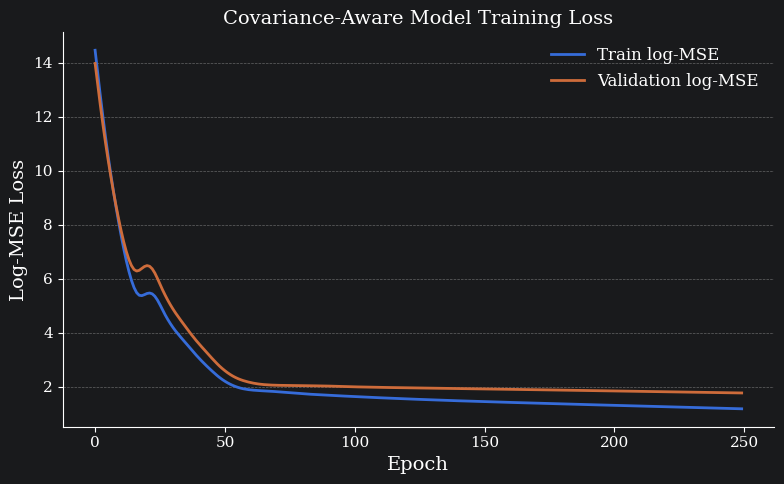

In [3]:
# Internal Validation Split
X_tr, X_va, y_tr, y_va, _, _ = stratified_train_val_split(
    X=X_tr_cov, y=y_tr_cov, modes=tr_modes, val_frac=0.2, seed=SEED
)

print("\nTraining Covariance-Aware MLP Regressor...")
cov_model, train_losses, val_losses = train_predictor(
    X_tr, y_tr, X_va, y_va, hidden_dim=64, num_epochs=250, lr=1e-3, seed=SEED
)

# Plot Loss
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label="Train log-MSE", linewidth=2)
ax.plot(val_losses, label="Validation log-MSE", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Log-MSE Loss")
ax.set_title("Covariance-Aware Model Training Loss")
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
def predict_covariance_lambda(model: LambdaPredictor, query_text: str) -> float:
    """Inference wrapper using the covariance extractor."""
    q_emb = ensure_1d(embedder.embed_single(query_text)).astype(np.float32)
    geom_feats = extract_covariance_features(q_emb, corpus_embeddings, corpus_norms)
    tensor_in = torch.tensor(np.concatenate([q_emb, geom_feats]), dtype=torch.float32).unsqueeze(0)
    return float(model.predict_lambda(tensor_in)[0])

def evaluate_retrieval(query_text, q_id, q_mode, lam_val, engine):
    """Runs the pricing engine and returns metrics."""
    engine.lambda_sparsity = lam_val
    result = engine.retrieve(query_text, verbose=False)
    selected_indices = get_selected_indices(result)
    relevant_indices = relevant_by_qid[q_id]

    _, metrics = complexity_aligned_lambda_score(selected_indices, relevant_indices, q_mode)
    metrics["total_reduced_cost"] = float(np.sum(result.reduced_costs)) if result.reduced_costs is not None else 0.0
    return metrics

print("Running Final End-to-End Evaluation on TEST SET...")

eval_engine = PricingEngine(
    segments=segments, embed_fn=embedder.embed_single,
    lambda_sparsity=0.05, eta_redundancy=0.0, max_segments=5
)

results = {"fixed_default": [], "fixed_best": [], "learned_cov": [], "oracle": []}

test_qids = set(r["question_id"] for r in test_records)
eval_questions = [q for q in questions if q.question_id in test_qids]

for q in eval_questions:
    results["fixed_default"].append(evaluate_retrieval(q.question, q.question_id, q.question_type, 0.05, eval_engine))
    results["fixed_best"].append(evaluate_retrieval(q.question, q.question_id, q.question_type, 0.10, eval_engine))

    dyn_lambda = predict_covariance_lambda(cov_model, q.question)
    results["learned_cov"].append(evaluate_retrieval(q.question, q.question_id, q.question_type, dyn_lambda, eval_engine))

    oracle_lam = next((r["lambda"] for r in test_records if r["question_id"] == q.question_id and r["is_optimal"]), 0.05)
    results["oracle"].append(evaluate_retrieval(q.question, q.question_id, q.question_type, oracle_lam, eval_engine))

print("\n\nCovariance-Aware Model Comparison vs Baselines (Unseen Test Set):")
print(f"{'Config':<18} {'AvgCov':>10} {'AvgSegs':>10} {'AvgPrec':>10} {'AvgRC':>10}")
print("-" * 62)

display_names = {
    "fixed_default": "Fixed (0.05)", "fixed_best": "Fixed (0.10)",
    "learned_cov": "Covariance MLP", "oracle": "Oracle"
}

for cfg in ["fixed_default", "fixed_best", "learned_cov", "oracle"]:
    covs = np.mean([r["evidence_coverage"] for r in results[cfg]])
    segs = np.mean([r["num_selected"] for r in results[cfg]])
    precs = np.mean([r["precision"] for r in results[cfg]])
    rcs = np.mean([r["total_reduced_cost"] for r in results[cfg]])

    print(f"{display_names[cfg]:<18} {covs:>10.3f} {segs:>10.2f} {precs:>10.3f} {rcs:>10.3f}")

Running Final End-to-End Evaluation on TEST SET...


Covariance-Aware Model Comparison vs Baselines (Unseen Test Set):
Config                 AvgCov    AvgSegs    AvgPrec      AvgRC
--------------------------------------------------------------
Fixed (0.05)            0.483       1.20      0.767     -0.519
Fixed (0.10)            0.483       1.00      0.800     -0.467
Covariance MLP          0.483       1.85      0.564     -0.538
Oracle                  0.567       1.70      0.762     -0.529
